In [97]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Face')

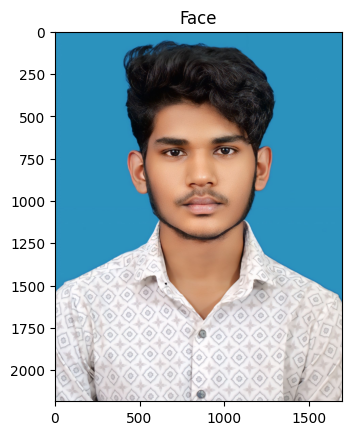

In [98]:
# Load the Face Image
faceImage = cv2.imread('deepak-pp.jpg')
plt.imshow(faceImage[:,:,::-1]);plt.title("Face")


In [99]:
faceImage.shape

(2184, 1698, 3)

In [100]:
#resized_faceImage.shape
faceImage.shape

(2184, 1698, 3)

Text(0.5, 1.0, 'glassPNG')

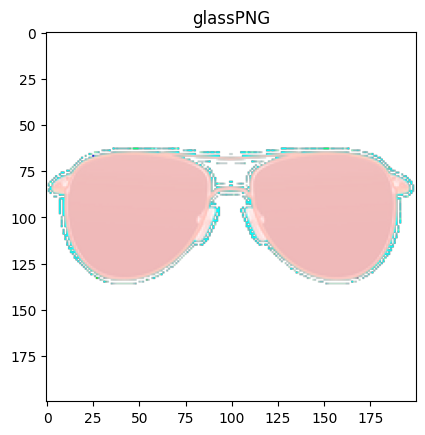

In [122]:
# Load the Sunglass image with Alpha channel
# (http://pluspng.com/sunglass-png-1104.html)
glassPNG = cv2.imread('sunglass.png',-1)
plt.imshow(glassPNG[:,:,::-1]);plt.title("glassPNG")

In [123]:
# Resize the image to fit over the eye region
glassPNG = cv2.resize(glassPNG,(175,700))
print("image Dimension ={}".format(glassPNG.shape))

image Dimension =(700, 175, 4)


In [124]:
# Separate the Color and alpha channels
glassBGR = glassPNG[:,:,0:3]
glassMask1 = glassPNG[:,:,3]

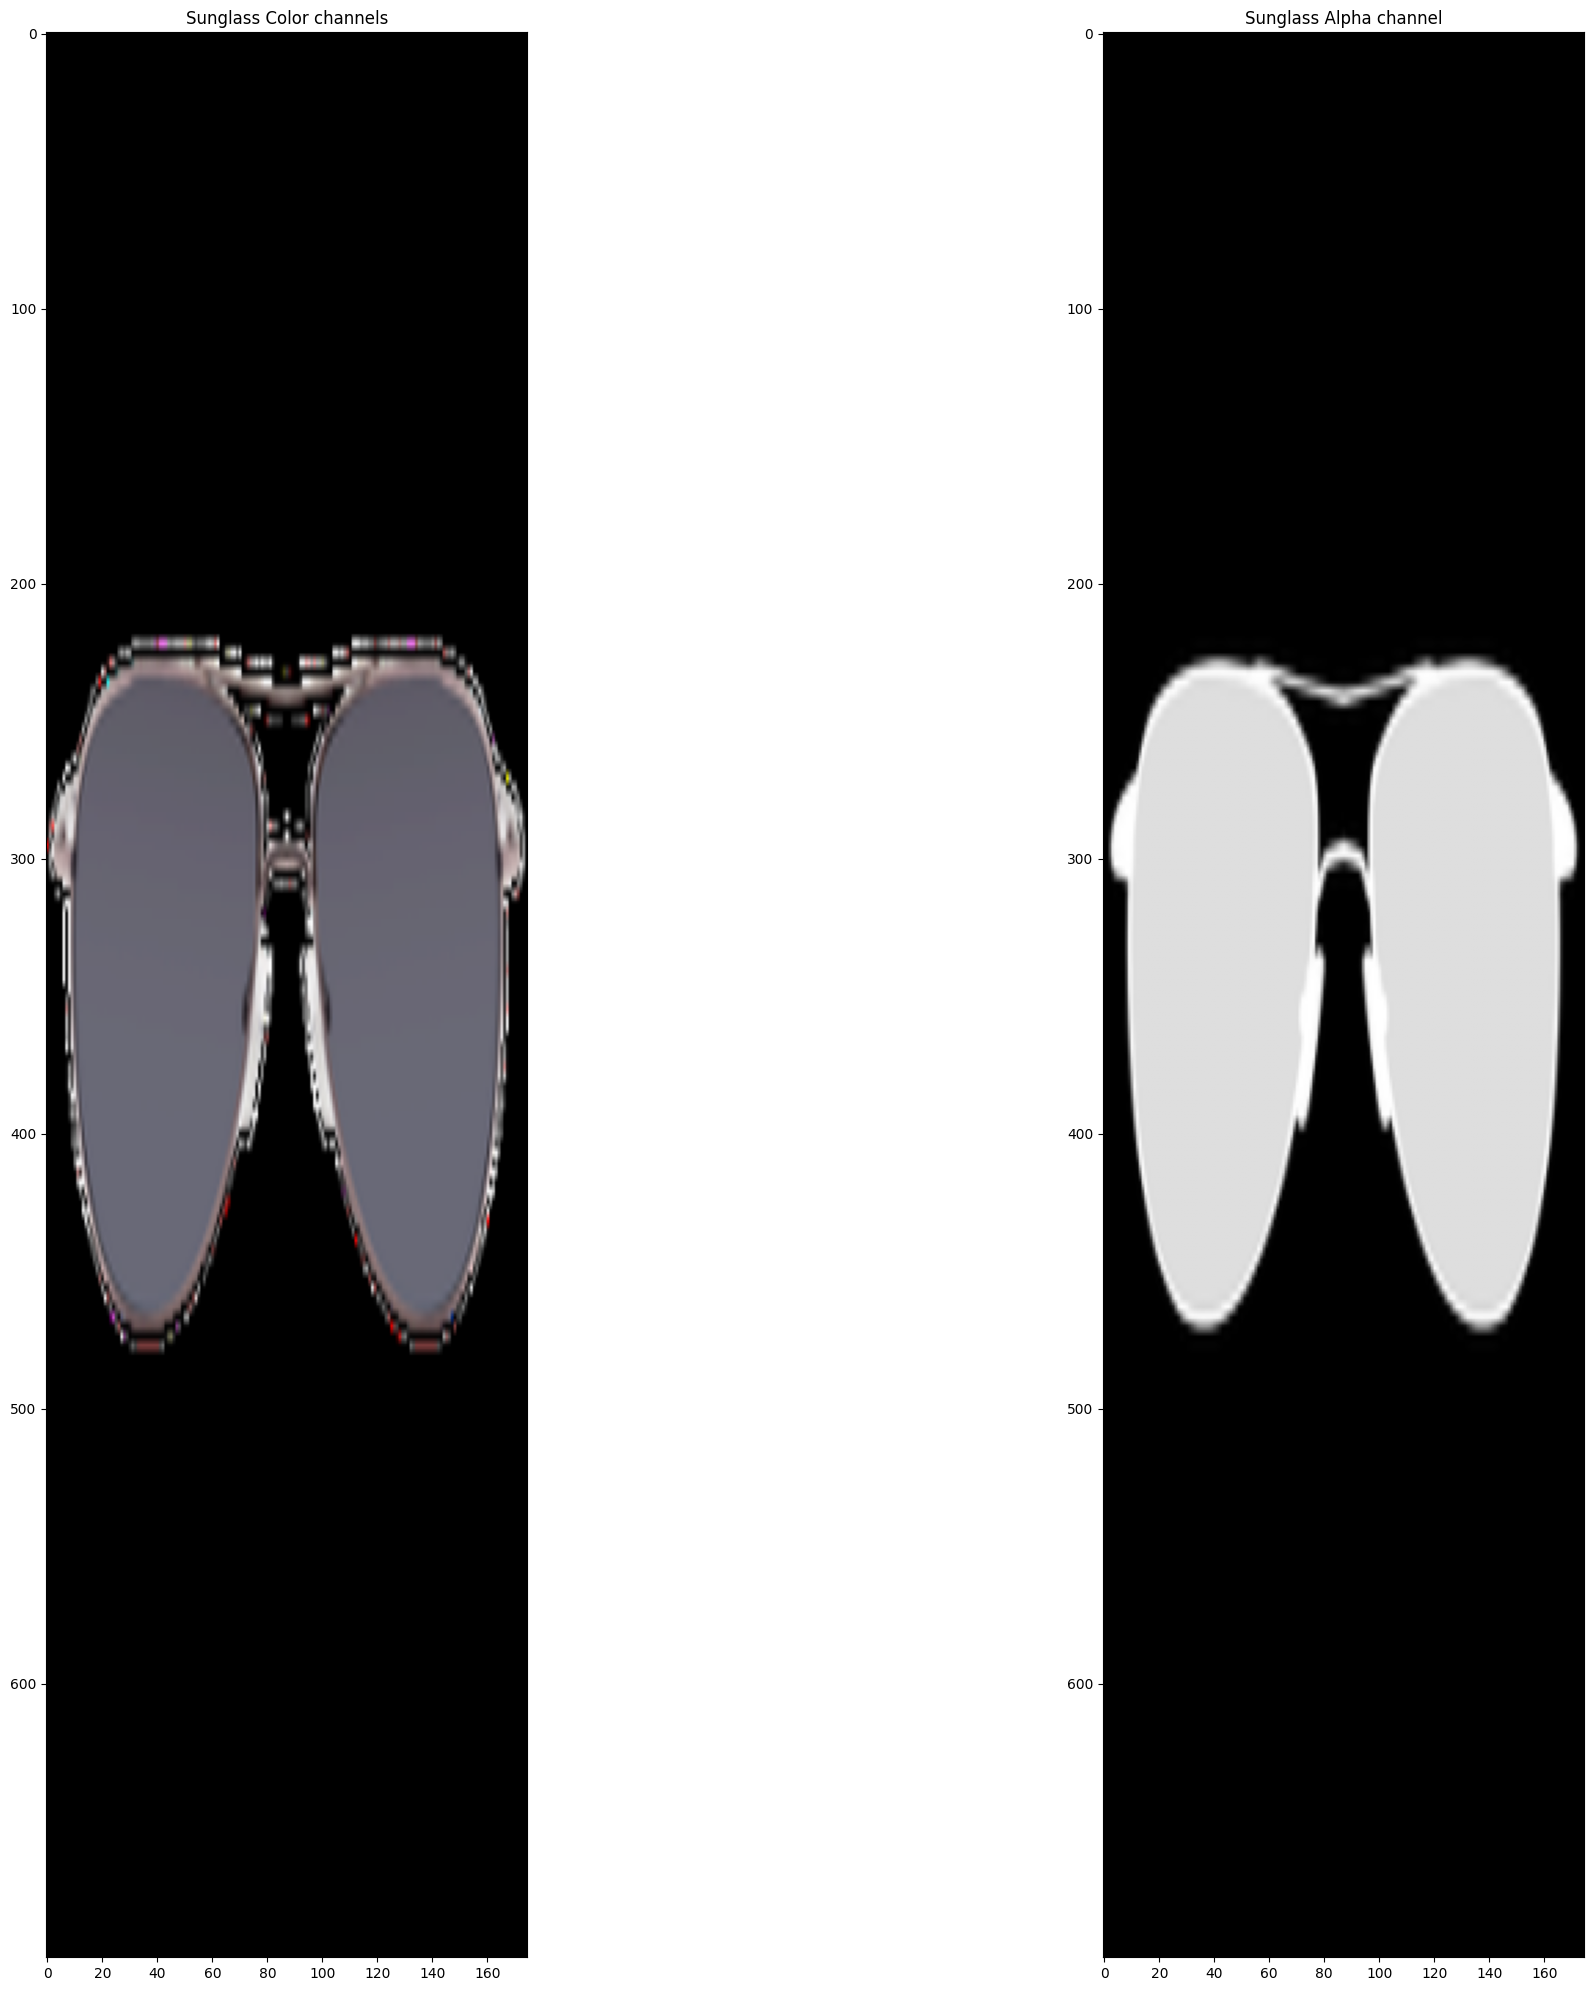

In [125]:
# Display the images for clarity
plt.figure(figsize=[25,25])
plt.subplot(121);plt.imshow(glassBGR[:,:,::-1]);plt.title('Sunglass Color channels');
plt.subplot(122);plt.imshow(glassMask1,cmap='gray');plt.title('Sunglass Alpha channel');

In [126]:
# Use (Width, Height) order for cv2.resize
# Based on your slice [625:800, 500:1200], width is 700 and height is 175
glassPNG = cv2.resize(glassPNG, (700, 175)) 

# Now the rest of your code will work:
glassBGR = glassPNG[:, :, 0:3]
faceWithGlassesNaive = faceImage.copy()
faceWithGlassesNaive[625:800, 500:1200] = glassBGR

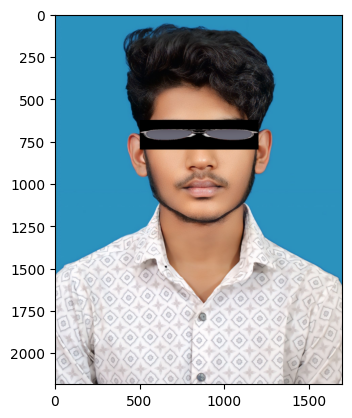

In [127]:
# Make a copy
#faceWithGlassesNaive = resized_faceImage.copy()
faceWithGlassesNaive = faceImage.copy()

# Replace the eye region with the sunglass image
faceWithGlassesNaive[625:800,500:1200]=glassBGR

plt.imshow(faceWithGlassesNaive[...,::-1])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..254.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..237.0].


Text(0.5, 1.0, 'Augmented Eye and Sunglass')

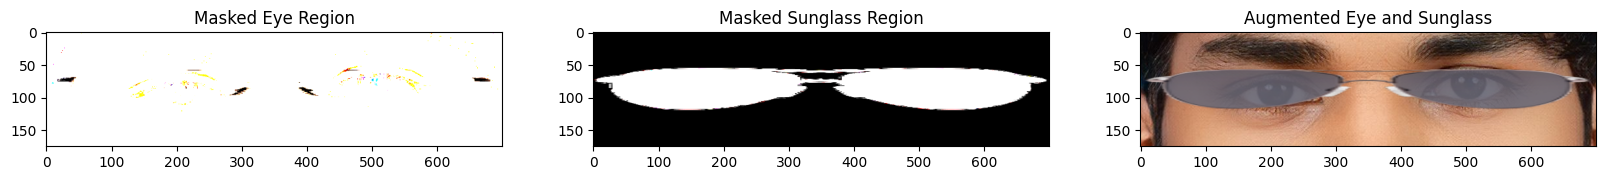

In [128]:
# 1. Ensure you are using the CORRECTLY resized glassPNG (700 wide, 175 tall)
# If you haven't already, redo the extraction:
glassBGR = glassPNG[:, :, 0:3]
glassMask1 = glassPNG[:, :, 3] # This will now be (175, 700)

# 2. Create the 3-channel mask
glassMask = cv2.merge((glassMask1, glassMask1, glassMask1))

# 3. Convert to float/scale for multiplication
# Note: Using float is safer for (1 - glassMask) operations to avoid uint8 underflow
glassMask = glassMask.astype(float) / 255.0

# 4. Perform the arithmetic
faceWithGlassesArithmetic = faceImage.copy()
eyeROI = faceWithGlassesArithmetic[625:800, 500:1200]

# Ensure eyeROI is also float for the multiplication
maskedEye = cv2.multiply(eyeROI.astype(float), (1.0 - glassMask))
maskedGlass = cv2.multiply(glassBGR.astype(float), glassMask)

# 5. Combine and convert back to uint8
eyeRoiFinal = cv2.add(maskedEye, maskedGlass).astype(np.uint8)

# Display the intermediate results
plt.figure(figsize=[20,20])
plt.subplot(131);plt.imshow(maskedEye[...,::-1]);plt.title("Masked Eye Region")
plt.subplot(132);plt.imshow(maskedGlass[...,::-1]);plt.title("Masked Sunglass Region")
plt.subplot(133);plt.imshow(eyeRoiFinal[...,::-1]);plt.title("Augmented Eye and Sunglass")

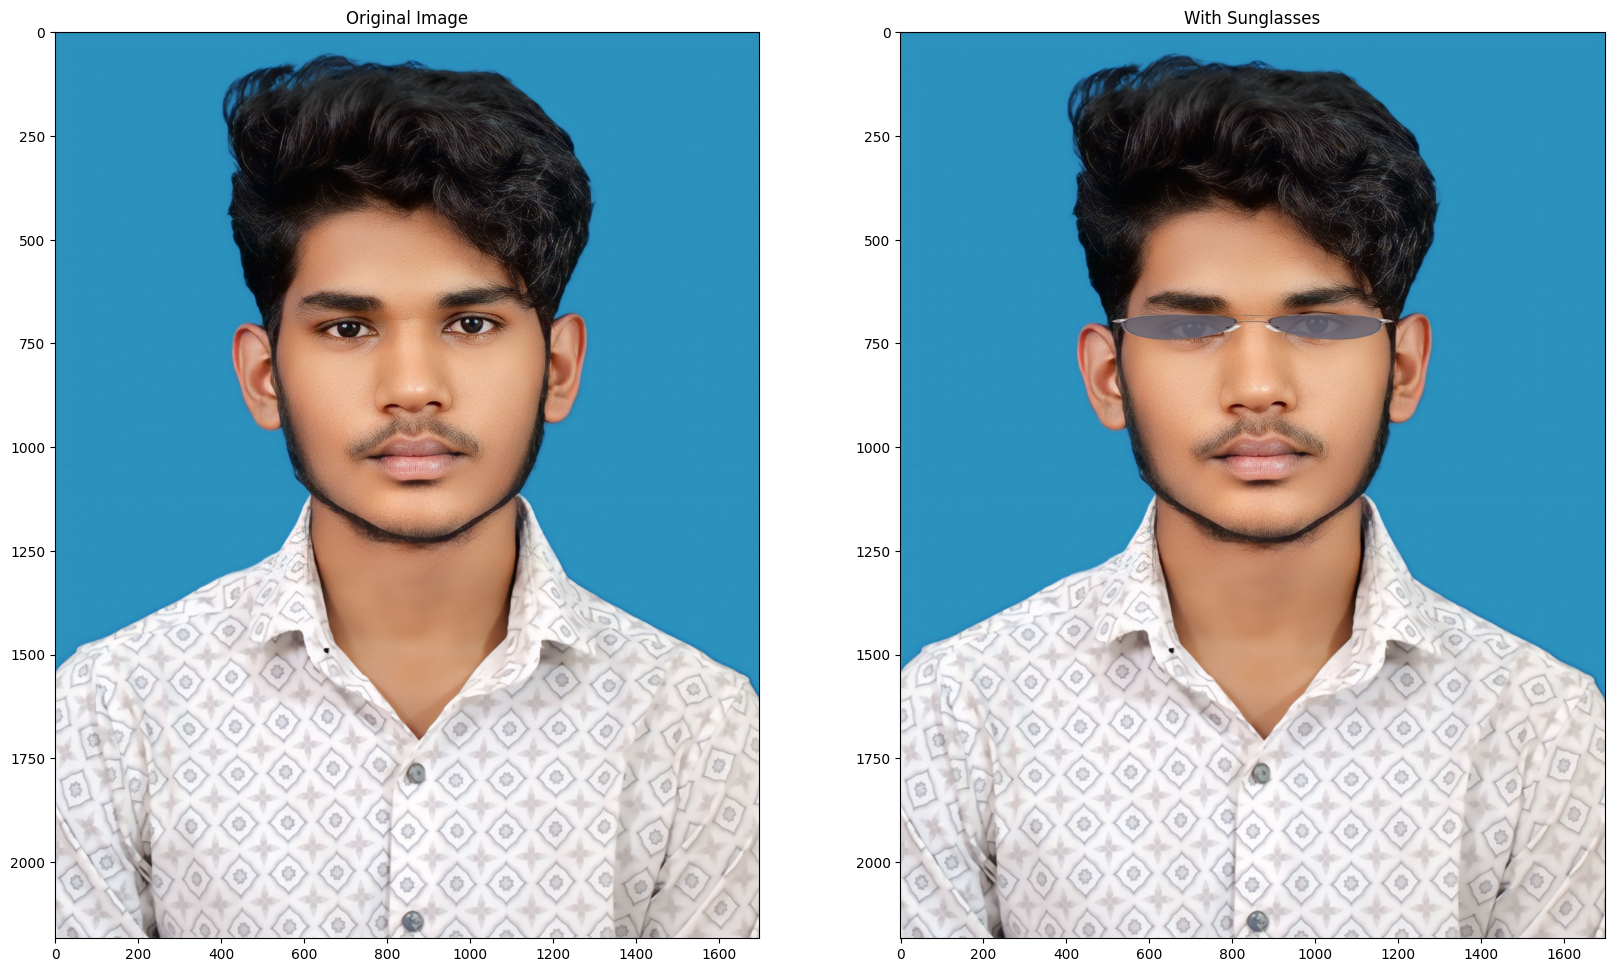

In [129]:
# Replace the eye ROI with the output from the previous section
faceWithGlassesArithmetic[625:800, 500:1200]=eyeRoiFinal

# Display the final result
plt.figure(figsize=[20,20]);
plt.subplot(121);plt.imshow(faceImage[:,:,::-1]); plt.title("Original Image");
plt.subplot(122);plt.imshow(faceWithGlassesArithmetic[:,:,::-1]);plt.title("With Sunglasses");